# Regression Model — California Housing

**Task:** Predict median house value (in 100k USD) from 8 numeric features.

**Model:** Random Forest Regressor (sklearn 1.2.x compatible).

**Pipeline:** `StandardScaler` → `RandomForestRegressor`.

**Deployed to:** AWS SageMaker (`ml.t2.medium`, sklearn 1.2-1 framework container).

Output: `model.joblib` + `metrics.json` saved to `ml/regression/`.

## 1. Imports and setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
OUT_DIR = Path('../ml/regression')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
df = df.rename(columns={'MedHouseVal': 'target'})
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis

In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Missing values
print('Missing values per column:')
print(df.isna().sum())

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


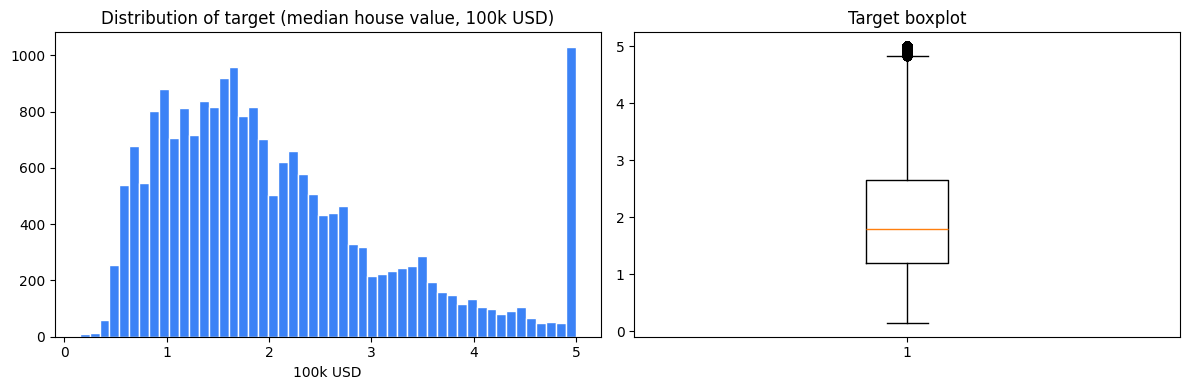

In [5]:
# Distribution of the target
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['target'], bins=50, color='#3b82f6', edgecolor='white')
ax[0].set_title('Distribution of target (median house value, 100k USD)')
ax[0].set_xlabel('100k USD')
ax[1].boxplot(df['target'])
ax[1].set_title('Target boxplot')
plt.tight_layout()
plt.show()

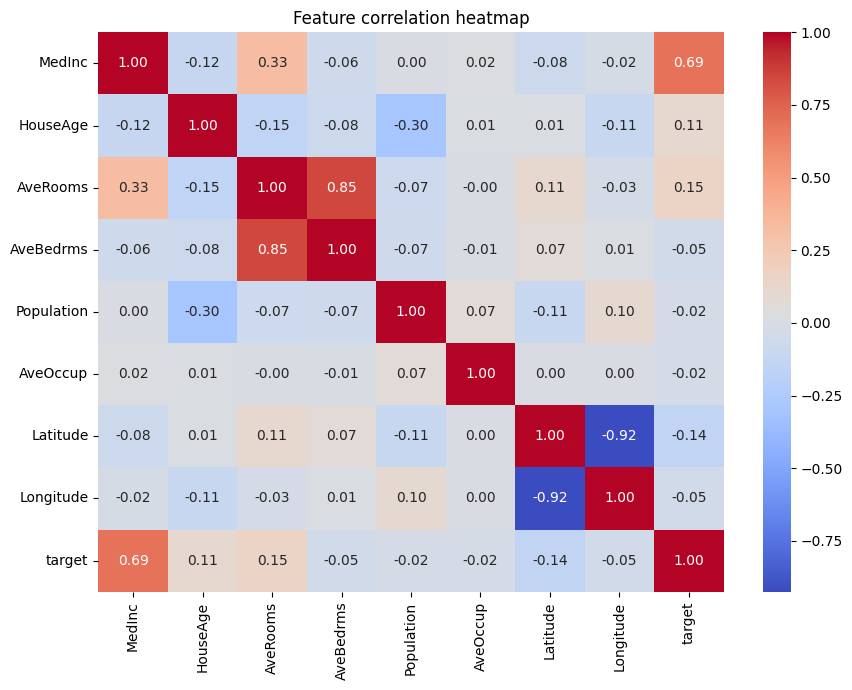

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature correlation heatmap')
plt.tight_layout()
plt.show()

**Observations:**
- Target is right-skewed with a hard cap around 5 (the dataset's known censoring at $500k).
- `MedInc` (median income) is the strongest positive correlate of house value.
- `Latitude` and `Longitude` are highly correlated with each other (geographic clustering).

## 4. Train/test split + scaling

In [7]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')

Train: (16512, 8),  Test: (4128, 8)


## 5. Train the Random Forest Regressor

Pipeline: `StandardScaler` → `RandomForestRegressor`. Random Forest is invariant to feature scale, but we keep the scaler in the pipeline for consistency with the inference container.

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=15, min_samples_split=5,
                                       n_jobs=-1, random_state=42))])

## 6. Evaluate on the test set

In [9]:
y_pred = pipe.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae = float(mean_absolute_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

print(f'RMSE: {rmse:.4f}  ({rmse * 100000:,.0f} USD)')
print(f'MAE:  {mae:.4f}  ({mae * 100000:,.0f} USD)')
print(f'R^2:  {r2:.4f}')

RMSE: 0.5102  (51,024 USD)
MAE:  0.3327  (33,270 USD)
R^2:  0.8013


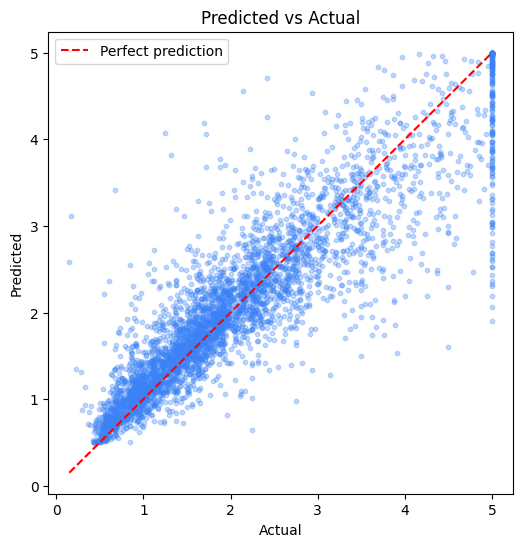

In [10]:
# Predicted vs actual
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='#3b82f6')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual')
ax.legend()
plt.show()

## 7. Feature importance

In [11]:
rf = pipe.named_steps['rf']
feature_importance = dict(zip(X.columns, rf.feature_importances_))
fi_sorted = sorted(feature_importance.items(), key=lambda kv: kv[1], reverse=True)
for name, imp in fi_sorted:
    print(f'  {name:12s}  {imp:.4f}')

  MedInc        0.5421
  AveOccup      0.1387
  Latitude      0.0872
  Longitude     0.0868
  HouseAge      0.0523
  AveRooms      0.0407
  Population    0.0266
  AveBedrms     0.0257


## 8. Save artifacts

In [12]:
joblib.dump(pipe, OUT_DIR / 'model.joblib')
metrics = {
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'feature_importance': {k: float(v) for k, v in feature_importance.items()},
}
(OUT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved:', OUT_DIR / 'model.joblib')
print('Saved:', OUT_DIR / 'metrics.json')

Saved: ../ml/regression/model.joblib
Saved: ../ml/regression/metrics.json


## 9. Inference contract

The deployed SageMaker endpoint expects a JSON payload with all 8 features:

```json
{
  "MedInc": 5.0, "HouseAge": 25, "AveRooms": 5.0, "AveBedrms": 1.0,
  "Population": 1500, "AveOccup": 3.0, "Latitude": 34.0, "Longitude": -118.0
}
```

Returns: `[{'predicted_value_usd': <int>}]`.

See `ml/regression/inference.py` for the full SageMaker handler.